Testing orchestration of the two agents (rooms and information) with LangGraph

In [1]:
from pathlib import Path

import nest_asyncio
from dotenv import load_dotenv

from blue_horizon.agents.information_agent import (
    AgentFactory,
    InfoRagResources,
    build_chat_model,
    get_redis_url,
    load_info_config,
    resolve_prompts_dir,
)
from blue_horizon.agents.rooms_sql_agent import (
    get_neon_db_url,
    get_rooms_agent,
    initialize_rooms_agent,
    load_rooms_sql_config,
)

nest_asyncio.apply()
load_dotenv()

gpt_model = "gpt-5-nano"

In [2]:
info_rag_config = load_info_config(Path.cwd() / "../blue_horizon/info_config.toml")
prompts_dir = resolve_prompts_dir()
info_rag_resources = InfoRagResources(redis_url=get_redis_url(), config=info_rag_config)
await info_rag_resources.startup_check()
info_chat_model = build_chat_model(cfg=info_rag_config.chat)
info_agent_factory = AgentFactory(resources=info_rag_resources, chat_model=info_chat_model, config=info_rag_config, prompts_dir=prompts_dir)

In [3]:
rooms_sql_config = load_rooms_sql_config(Path.cwd() / "../blue_horizon/rooms_sql_config.toml")
neon_db_url = get_neon_db_url()
await initialize_rooms_agent(config=rooms_sql_config, neon_db_url=neon_db_url)

In [7]:
info_agent = info_agent_factory.build()
rooms_agent = await get_rooms_agent(config=rooms_sql_config, neon_db_url=neon_db_url)

In [8]:
def get_output_text(query_result) -> str:
    last_result = query_result["messages"][-1]
    for c in last_result.content:
        if "text" in c:
            return c["text"]
    return ""

In [9]:
prompt = "What dining options are there?"
result = await info_agent.ainvoke({"messages": [{"role": "user", "content": prompt}]})
print(get_output_text(result))

Here’s what I found about the hotel’s dining options:

Room service is available 24/7, with a full menu during restaurant hours and a limited menu overnight.

Breakfast is included with most room rates—please check your booking details.

The hotel offers an on-site restaurant and 24-hour room service (along with other amenities like complimentary Wi‑Fi, fitness center, pool, and spa).

**Breakfast in Bed**
  **Category:** Room Service
  **Price (USD):** 45
  **Duration (minutes):** 30
  **Availability:** 8:00-20:00
  **Booking required:** True
  **Minimum notice (hours):** 1
  **Description:** Savor the luxury of our Breakfast in Bed, a 30-minute culinary experience that satisfies your gourmet cravings. Our expert staff will careful temperature control, ensuring culinary delight.

I couldn’t find additional specific on-site venues (e.g., bar/café names or restaurant hours) in the available details I searched.  
Is there any other information I can provide about the hotel? I can also he

In [13]:
prompt = 'Show me rooms with a view of the ocean and a 55" TV'
result = await rooms_agent.ainvoke({"messages": [{"role": "user", "content": prompt}]})
print(get_output_text(result))

I found these rooms with an ocean view and a 55" Smart TV (showing up to 4):

- Room 502 — Floor 5 — Deluxe — 460 sq ft — Max occupancy 3 — Bed: Double Queen  
  Views: Pool View, Ocean View  
  Amenities: Air Conditioning, 55" Smart TV, Nespresso Machine, Mini Fridge, Hair Dryer, In-Room Safe, Work Desk, High-Speed WiFi, Bluetooth Speaker, Microwave, Premium Bathrobes, Designer Slippers, Evening Turndown Service  
  Additional: Soaking Tub  
  Accessible: No

- Room 503 — Floor 5 — Deluxe — 538 sq ft — Max occupancy 3 — Bed: Double Queen  
  Views: Pool View, Ocean View  
  Amenities: Air Conditioning, 55" Smart TV, Nespresso Machine, Mini Fridge, Hair Dryer, In-Room Safe, Work Desk, High-Speed WiFi, Bluetooth Speaker, Microwave, Premium Bathrobes, Designer Slippers, Evening Turndown Service  
  Additional: Soaking Tub, Lounge Access, Balcony  
  Accessible: No

- Room 504 — Floor 5 — Deluxe — 565 sq ft — Max occupancy 3 — Bed: Double Queen  
  Views: Ocean View  
  Amenities: Air Con

In [10]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=gpt_model, temperature=0, reasoning={"effort": "low"})

In [33]:
from typing import Literal

from langgraph.graph import MessagesState
from pydantic import BaseModel, Field


class Route(BaseModel):
    step: Literal["info", "rooms", "none"] = Field(
        description="The next step to take in answering the user's query.")

class State(MessagesState):
    route: str | None

router = llm.with_structured_output(Route)

In [34]:
from langchain.messages import SystemMessage

system_prompt = """You are a routing classifier for a hotel chatbot.

## Task

Given the full chat history and the latest user message, choose the single next step:

* **"rooms"**: The user is asking about hotel rooms, room availability, room pricing/options, or taking an action in a reservation flow (selecting a room, confirming details, booking, modifying, canceling).
* **"info"**: The user is asking for any other hotel information (FAQs, amenities, services, and **all hotel policies**).
* **"none"**: The user's request is unrelated to this hotel or outside supported scope (supported scope is: hotel info + room search/booking/modification/cancellation).

## Output constraints (non-negotiable)

* Output MUST be valid structured output with **exactly one field**: `step`.
* `step` MUST be one of: `"info"`, `"rooms"`, `"none"`.
* Do NOT output explanations, extra keys, markdown, or any other text.

## What the rooms agent can know (ground truth)

The rooms agent's room-details knowledge is limited to fields like:

* **type**, **bed_type**, **view_type**
* **max_occupancy**, **square_feet**
* **floor**, **room_number**
* **accessibility** (e.g., accessible vs not)
* **basic_amenities** and **additional_amenities** (in-room features)
* **last_renovation**
* **base_rate** and **max_rate** (rate range)
* **status** (a room-level status label)

All **hotel policies** (cancellation policy, check-in/out policy, pet/smoking/payment/refund rules, etc.) belong to the **info** agent.

## Routing rules

### 1) Booking-flow state (highest priority)

If recent assistant turns were about room options, availability, pricing, booking details, or an existing reservation, and the user is responding with confirmation or selection (e.g., “yes”, “book it”, “that one”, “the cheaper option”, “same dates”, “change it to…”, “cancel it”), choose **"rooms"**.

### 2) Rooms intent

Choose **"rooms"** if the user asks about or requests actions involving:

* Room inventory: what rooms exist, what room types are available, comparing room types
* Room attributes: type, bed type, view type, square footage, floor, accessibility, max occupancy, renovation recency
* In-room features: anything that would be found under room **basic_amenities** / **additional_amenities** (e.g., TV, coffee maker, city view, turndown service, etc.)
* Availability for dates, rates, totals, choosing between options, upgrades/downgrades
* Booking a room or confirming booking details
* **Modifying or canceling an existing reservation**

Important keyword traps:

* “room service” is a hotel service question → choose **"info"** unless the user is explicitly making/changing/canceling a room reservation.
* “amenities” could mean hotel-wide amenities or in-room amenities:

  * If the user is asking about **in-room** features → **"rooms"**.
  * If the user is asking about **hotel-wide** amenities (pool, gym, spa, etc.) → **"info"**.

### 3) Hotel info intent (includes all policies)

Choose **"info"** if the user asks about:

* Hotel-wide amenities and services (pool, gym, Wi-Fi, shuttle, spa, dining, parking, directions/location, hours)
* **Any hotel policy** (cancellation policy, check-in/out policy, pet policy, smoking policy, payment/refund rules, ID requirements, incidentals, etc.)

### 4) Mixed intent (must pick one; never pick "none")

If the message contains both room-related and info-related intent, choose the intent that is **blocking the next action**.

* If moving forward requires room selection/availability/booking/modification/cancellation → choose **"rooms"**.
* Otherwise → choose **"info"**.
* Do NOT choose **"none"** for mixed intent.

### 5) None

Choose **"none"** only when the user request is not about this hotel's information or room search/booking/modification/cancellation.

## Examples (guidance only)

* “Do you have a king room next Friday?” → rooms
* “Show me accessible rooms with a city view.” → rooms
* “Which rooms have turndown service?” → rooms
* “Book the second option for 2 nights.” → rooms
* “Cancel my reservation.” → rooms
* “Change my booking to a double queen.” → rooms
* “What's your cancellation policy?” → info
* “What time does the pool close?” → info
* “What are room service hours?” → info
* “Write me a poem.” → none
"""

def router_llm(state: State) -> dict:
    """Route the user's query to the appropriate agent."""
    messages = state["messages"]
    decision = router.invoke([SystemMessage(content = system_prompt), *messages])
    return {"route": getattr(decision, "step", None)}



In [35]:
from langchain.messages import HumanMessage
from langgraph.graph import END, START, StateGraph

agent_graph = StateGraph(State)

agent_graph.add_node("router_llm", router_llm)

agent_graph.add_edge(START, "router_llm")
agent_graph.add_edge("router_llm", END)
agent_built = agent_graph.compile()

In [36]:
prompt = "What's your room service like?"
state = agent_built.invoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content="What's your room service like?", additional_kwargs={}, response_metadata={}, id='b7c6e786-8ec3-4815-bf28-3c3448636398')],
 'route': 'info'}

In [43]:
from langchain.messages import AIMessage
from langgraph.graph import END, START, StateGraph

async def info_agent_call(state: State):
    return await info_agent.ainvoke(state)

async def rooms_agent_call(state: State):
    return await rooms_agent.ainvoke(state)

def refuse_call(state: State):
    refusal_message = "I'm sorry, I cannot help with that query. I can only provide "
    refusal_message += "information about the hotel and help with room bookings."
    state["messages"].append(AIMessage([{"type": "text", "text": refusal_message}]))

def route_decision(state: State):
    return state["route"]

agent_graph = StateGraph(State)

agent_graph.add_node("router_llm", router_llm)
agent_graph.add_node("info_agent_call", info_agent_call)
agent_graph.add_node("rooms_agent_call", rooms_agent_call)
agent_graph.add_node("refuse_call", refuse_call)

agent_graph.add_edge(START, "router_llm")
agent_graph.add_conditional_edges("router_llm", route_decision,
                                  {"info": "info_agent_call",
                                   "rooms": "rooms_agent_call",
                                   "none": "refuse_call"})
agent_graph.add_edge("info_agent_call", END)
agent_graph.add_edge("rooms_agent_call", END)
agent_graph.add_edge("refuse_call", END)

agent_built = agent_graph.compile()

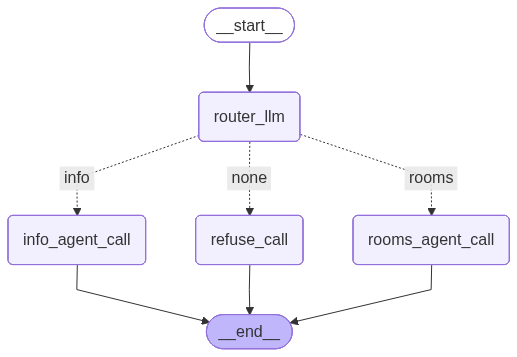

In [44]:
from IPython.display import Image, display

display(Image(agent_built.get_graph().draw_mermaid_png()))

In [41]:
prompt = "What's your room service like?"
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content="What's your room service like?", additional_kwargs={}, response_metadata={}, id='68b5442e-8e45-41b9-bf66-6406ebeabed5'),
  AIMessage(content=[{'id': 'rs_020f8b443385752800696c3a679d408190919de0f3541541c9', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"room service hours menu in-room dining how does room service work"}', 'call_id': 'call_3XuLbXCp5tkOFA1N5MKFLGJN', 'name': 'query_faq', 'type': 'function_call', 'id': 'fc_020f8b443385752800696c3a68537c819089d47a4982237729', 'status': 'completed'}, {'arguments': '{"query":"room service in-room dining","booking_required":null,"min_price":null,"max_price":null,"min_notice_hours":null,"max_notice_hours":null,"min_duration_minutes":null,"max_duration_minutes":null}', 'call_id': 'call_JfW86IEbQMADxakU6iaxwz4v', 'name': 'query_amenities', 'type': 'function_call', 'id': 'fc_020f8b443385752800696c3a68d73081909dd227572140c83d', 'status': 'completed'}, {'arguments': '{"query":"room service in-room d

In [45]:
prompt = "What is the answer to the ultimate question of life, the universe, and everything?"
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content='What is the answer to the ultimate question of life, the universe, and everything?', additional_kwargs={}, response_metadata={}, id='e22713d0-2f0f-4f31-8969-c19908736d96'),
  AIMessage(content=[{'type': 'text', 'text': "I'm sorry, I cannot help with that query. I can only provide information about the hotel and help with room bookings."}], additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'route': 'none'}

In [46]:
prompt = "What is the name of the hotel?"
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content='What is the name of the hotel?', additional_kwargs={}, response_metadata={}, id='e9f0b714-6053-4d50-a806-c23630ec3faf'),
  AIMessage(content=[{'id': 'rs_0b36a1302d7445d100696c3bc172b881939bbbe5675e5c89fc', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"name of the hotel hotel name property name"}', 'call_id': 'call_1gSm8xYE2f06Cds7cDA4y79i', 'name': 'query_faq', 'type': 'function_call', 'id': 'fc_0b36a1302d7445d100696c3bc1f2108193bb9f39850d275301', 'status': 'completed'}, {'arguments': '{"query":"hotel name property name","booking_required":null,"min_price":null,"max_price":null,"min_notice_hours":null,"max_notice_hours":null,"min_duration_minutes":null,"max_duration_minutes":null}', 'call_id': 'call_ZyKLuy2cQMzZR2wNIZGbhnfU', 'name': 'query_amenities', 'type': 'function_call', 'id': 'fc_0b36a1302d7445d100696c3bc2780081939f8d4ef3f46ec8d6', 'status': 'completed'}, {'arguments': '{"query":"hotel name property name","booking_required":nul

In [47]:
prompt = 'I want a 75" TV'
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

discarding closed connection: <psycopg.AsyncConnection [BAD] at 0x28b75388e90>
run_sql transient DB/pool error; retrying (attempt=1/2)
Traceback (most recent call last):
  File "G:\My Drive\Coding_interviews\Interview Kickstart ML Projects\Blue Horizon\Blue-Horizon-AI-Concierge\blue_horizon\agents\rooms_sql_agent.py", line 862, in run_sql
    await cur.execute(cast("LiteralString", query))
  File "d:\pypoetry\Cache\virtualenvs\blue-horizon-cYemaw-w-py3.13\Lib\site-packages\psycopg\cursor_async.py", line 117, in execute
    raise ex.with_traceback(None)
psycopg.OperationalError: consuming input failed: SSL connection has been closed unexpectedly
discarding closed connection: <psycopg.AsyncConnection [BAD] at 0x28b7538a520>
run_sql DB/pool operation failed (attempt=2/2)
Traceback (most recent call last):
  File "G:\My Drive\Coding_interviews\Interview Kickstart ML Projects\Blue Horizon\Blue-Horizon-AI-Concierge\blue_horizon\agents\rooms_sql_agent.py", line 862, in run_sql
    await cur.e

{'messages': [HumanMessage(content='I want a 75" TV', additional_kwargs={}, response_metadata={}, id='65f5ef8f-6786-4f6b-bfcf-e9cbf2b1adee'),
  AIMessage(content=[{'id': 'rs_0c642ab864ac99aa00696c3be267c08193a93bcd9a1bb37060', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"SELECT room_number, floor, type, square_feet, basic_amenities, additional_amenities, bed_type, view_type, max_occupancy, accessibility\\nFROM rooms\\nWHERE (basic_amenities IS NOT NULL AND basic_amenities @> ARRAY[$$Multiple 75\\" Smart TVs$$]::text[])\\n   OR (additional_amenities IS NOT NULL AND additional_amenities @> ARRAY[$$Multiple 75\\" Smart TVs$$]::text[])\\nORDER BY floor, room_number\\nLIMIT 4"}', 'call_id': 'call_dJsKxdDPpX8jzWeK8RFP4kAy', 'name': 'run_sql', 'type': 'function_call', 'id': 'fc_0c642ab864ac99aa00696c3be64f188193b381bee2e9bc750b', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0c642ab864ac99aa00696c3be2095c8193bb399c8dbfa2756a', 'created_at': 176

In [48]:
prompt = "You suggested room 101. Does that pad have WiFi?"
state = await agent_built.ainvoke(State(messages=[HumanMessage(content=prompt)], route=None))
state

{'messages': [HumanMessage(content='You suggested room 101. Does that pad have WiFi?', additional_kwargs={}, response_metadata={}, id='ea8bd566-7584-48ac-a2c9-8769870c8faa'),
  AIMessage(content=[{'id': 'rs_01c892f7c9b2041c00696c3c1aad4c8196984188ef5980b60c', 'summary': [], 'type': 'reasoning'}, {'arguments': '{"query":"SELECT room_number, basic_amenities, additional_amenities FROM rooms WHERE room_number = 101 LIMIT 1"}', 'call_id': 'call_CaI3JnY5AAwbHp97QGBMFPMd', 'name': 'run_sql', 'type': 'function_call', 'id': 'fc_01c892f7c9b2041c00696c3c1cfebc81969b85b29b27d3f44d', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_01c892f7c9b2041c00696c3c1a5920819683a707e29fefe920', 'created_at': 1768700954.0, 'metadata': {}, 'model': 'gpt-5-mini-2025-08-07', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07'}, id='resp_01c892f7c9b2041c00696c3c1a5920819683a707e29fefe920', tool_calls=